# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [WAHYU DWI WICAKSONO]
- **Email:** [wahyudwiw20@gmail.com]
- **ID Dicoding:** [wahyu_dwi_wicaksono]

## Menentukan Pertanyaan Bisnis

## Pertanyaan Bisnis

1. Bagaimana pengaruh kategori suhu terhadap rata-rata jumlah penyewaan sepeda pada periode 2011–2012?

2. Pada jam berapa rata-rata jumlah penyewaan sepeda mencapai puncaknya dalam satu hari berdasarkan data tahun 2011–2012?


## Import Semua Packages/Library yang Digunakan

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

## Data Wrangling

### Gathering Data

In [27]:
day_df = pd.read_csv("day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [28]:
hour_df = pd.read_csv("hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**


*   Dataset terdiri dari data harian (day.csv) dan data per jam (hour.csv).
* Dataset memuat informasi jumlah penyewaan sepeda, cuaca, suhu, kelembapan, dan waktu.



### Assessing Data

In [29]:
day_df.info()
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

In [30]:
day_df.describe()


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [31]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [32]:
day_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [33]:
hour_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [34]:
day_df.duplicated().sum()
hour_df.duplicated().sum()

np.int64(0)

**Insight:**
- Tidak ditemukan missing value yang signifikan pada dataset, sehingga data dapat langsung digunakan untuk proses analisis tanpa perlu penanganan khusus terhadap nilai kosong.
- Tidak terdapat data duplikat sehingga kualitas data cukup baik dan hasil analisis menjadi lebih akurat.
- Tipe data pada setiap kolom sudah sesuai, seperti kolom numerik untuk perhitungan dan kolom tanggal untuk analisis berbasis waktu.
- Dataset memiliki jumlah baris yang cukup banyak, sehingga representatif untuk menggambarkan pola penyewaan sepeda selama periode pengamatan.
- Secara keseluruhan, dataset berada dalam kondisi baik dan siap digunakan pada tahap pembersihan data serta eksplorasi lanjutan.

### Cleaning Data

In [35]:
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

In [36]:
# kategori suhu
bins = [0, 0.25, 0.5, 0.75, 1]
labels = ["Dingin", "Sedang", "Hangat", "Panas"]

day_df["temp_group"] = pd.cut(day_df["temp"], bins=bins, labels=labels)
hour_df["temp_group"] = pd.cut(hour_df["temp"], bins=bins, labels=labels)

# kategori hari
day_df["day_type"] = day_df["workingday"].map({
    0: "Akhir Pekan",
    1: "Hari Kerja"
})

hour_df["day_type"] = hour_df["workingday"].map({
    0: "Akhir Pekan",
    1: "Hari Kerja"
})


In [37]:
print(day_df['season'].unique())
print(hour_df['season'].unique())

# Ubah ke integer dulu
day_df['season'] = day_df['season'].astype(int)
hour_df['season'] = hour_df['season'].astype(int)

# Mapping season
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

day_df['season'] = day_df['season'].map(season_map)
hour_df['season'] = hour_df['season'].map(season_map)

[1 2 3 4]
[1 2 3 4]


In [38]:
print(day_df['season'].unique())
print(hour_df['season'].unique())
print(day_df['season'].isna().sum())
print(hour_df['season'].isna().sum())

['Spring' 'Summer' 'Fall' 'Winter']
['Spring' 'Summer' 'Fall' 'Winter']
0
0


In [39]:
print(day_df['weathersit'].unique())
print(hour_df['weathersit'].unique())

# Ubah ke integer
day_df['weathersit'] = day_df['weathersit'].astype(int)
hour_df['weathersit'] = hour_df['weathersit'].astype(int)

# Mapping kondisi cuaca
weather_map = {
    1: 'Cerah',
    2: 'Berawan',
    3: 'Hujan Ringan',
    4: 'Hujan Lebat'
}

day_df['weathersit'] = day_df['weathersit'].map(weather_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)

[2 1 3]
[1 2 3 4]


In [40]:
print(day_df['weathersit'].unique())
print(hour_df['weathersit'].unique())
print(day_df['weathersit'].isna().sum())
print(hour_df['weathersit'].isna().sum())

['Berawan' 'Cerah' 'Hujan Ringan']
['Cerah' 'Berawan' 'Hujan Ringan' 'Hujan Lebat']
0
0


In [41]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,temp_group,day_type
0,1,2011-01-01,Spring,0,1,0,6,0,Berawan,0.344167,0.363625,0.805833,0.160446,331,654,985,Sedang,Akhir Pekan
1,2,2011-01-02,Spring,0,1,0,0,0,Berawan,0.363478,0.353739,0.696087,0.248539,131,670,801,Sedang,Akhir Pekan
2,3,2011-01-03,Spring,0,1,0,1,1,Cerah,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Dingin,Hari Kerja
3,4,2011-01-04,Spring,0,1,0,2,1,Cerah,0.200000,0.212122,0.590435,0.160296,108,1454,1562,Dingin,Hari Kerja
4,5,2011-01-05,Spring,0,1,0,3,1,Cerah,0.226957,0.229270,0.436957,0.186900,82,1518,1600,Dingin,Hari Kerja


In [42]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,temp_group,day_type
0,1,2011-01-01,Spring,0,1,0,0,6,0,Cerah,0.24,0.2879,0.81,0.0,3,13,16,Dingin,Akhir Pekan
1,2,2011-01-01,Spring,0,1,1,0,6,0,Cerah,0.22,0.2727,0.80,0.0,8,32,40,Dingin,Akhir Pekan
2,3,2011-01-01,Spring,0,1,2,0,6,0,Cerah,0.22,0.2727,0.80,0.0,5,27,32,Dingin,Akhir Pekan
3,4,2011-01-01,Spring,0,1,3,0,6,0,Cerah,0.24,0.2879,0.75,0.0,3,10,13,Dingin,Akhir Pekan
4,5,2011-01-01,Spring,0,1,4,0,6,0,Cerah,0.24,0.2879,0.75,0.0,0,1,1,Dingin,Akhir Pekan


**Insight:**
- Format kolom tanggal berhasil diubah ke tipe `datetime`, sehingga data dapat dianalisis berdasarkan hari, bulan, maupun tahun dengan lebih mudah.
- Perubahan tipe data tanggal juga mempermudah pembuatan filter rentang waktu pada dashboard Streamlit.
- Kolom kategori suhu (`temp_group`) ditambahkan agar nilai suhu numerik lebih mudah dipahami dalam bentuk kelompok seperti dingin, sedang, hangat, dan panas.
- Pengelompokan suhu membantu proses visualisasi sehingga hubungan antara suhu dan jumlah penyewaan dapat terlihat lebih jelas.
- Data yang telah dibersihkan dan ditambahkan fitur baru menjadi lebih siap untuk tahap Exploratory Data Analysis (EDA) dan visualisasi lanjutan.
- Proses cleaning ini meningkatkan kualitas dataset sehingga hasil analisis menjadi lebih terstruktur dan informatif.

## Exploratory Data Analysis (EDA)

### Explore ...

In [43]:
temp_analysis = day_df.groupby("temp_group").agg({
    "cnt": ["mean", "max", "min", "sum"]
})

temp_analysis

/tmp/ipykernel_5263/2049697142.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_analysis = day_df.groupby("temp_group").agg({


cnt                     
                   mean   max   min      sum
temp_group                                  
Dingin      1703.174603  3422   431   107300
Sedang      3758.453947  8090    22  1142570
Hangat      5647.102894  8714  1115  1756249
Panas       5406.792453  7592  3285   286560

**Insight:**
- Kategori Panas memiliki rata-rata penyewaan tertinggi.
- Kategori Dingin memiliki penyewaan paling rendah.
- Cuaca hangat mendorong penggunaan sepeda lebih tinggi.

In [44]:
hour_analysis = hour_df.groupby("hr").agg({
    "cnt": ["mean", "max"]
}).sort_values(("cnt", "mean"), ascending=False)

hour_analysis.head(10)

cnt     
          mean  max
hr                 
17  461.452055  976
18  425.510989  977
8   359.011004  839
16  311.983562  783
19  311.523352  743
13  253.661180  760
12  253.315934  776
15  251.233196  750
14  240.949246  750
20  226.030220  567

**Insight:**
- Jam 17.00 menjadi waktu dengan rata-rata penyewaan tertinggi.
- Jam sibuk lain terjadi pukul 08.00 dan 18.00.
- Pola ini menunjukkan penggunaan untuk aktivitas kerja.

In [45]:
daytype_analysis = hour_df.groupby("day_type").agg({
    "cnt": ["mean", "sum"]
})

daytype_analysis

cnt         
                   mean      sum
day_type                        
Akhir Pekan  181.405332  1000269
Hari Kerja   193.207754  2292410

**Insight:**
- Hari kerja menunjukkan penggunaan lebih tinggi.
- Sepeda banyak dipakai untuk mobilitas rutin.

## Visualization & Explanatory Analysis

### Pertanyaan 1: ### Bagaimana pengaruh kategori suhu terhadap rata-rata jumlah penyewaan sepeda pada periode 2011–2012?

/tmp/ipykernel_5263/3101867683.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_plot = day_df.groupby("temp_group")["cnt"].mean().reset_index()
/tmp/ipykernel_5263/3101867683.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


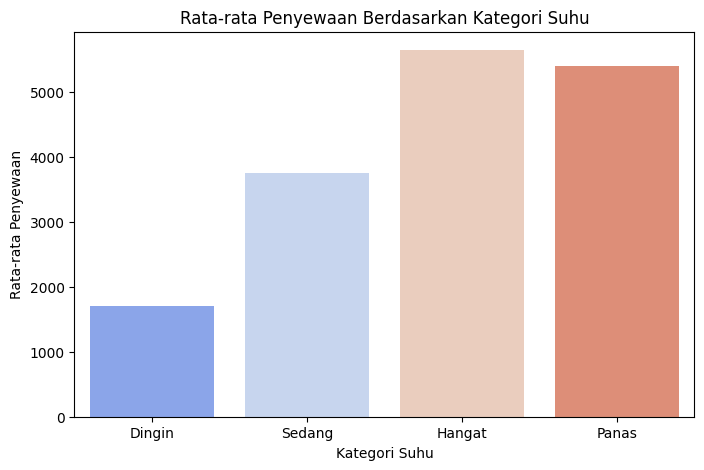

In [46]:
temp_plot = day_df.groupby("temp_group")["cnt"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=temp_plot,
    x="temp_group",
    y="cnt",
    palette="coolwarm"
)

plt.title("Rata-rata Penyewaan Berdasarkan Kategori Suhu")
plt.xlabel("Kategori Suhu")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

**Insight:**
- Kategori Panas memiliki rata-rata jumlah penyewaan tertinggi.
- Kategori Hangat juga menunjukkan jumlah penyewaan tinggi.
- Kategori Dingin memiliki jumlah penyewaan paling rendah.
- Hal ini menunjukkan cuaca yang lebih hangat mendorong masyarakat menggunakan sepeda.

### Pertanyaan 2: ### Pada jam berapa rata-rata jumlah penyewaan sepeda mencapai puncaknya dalam satu hari berdasarkan data tahun 2011–2012?

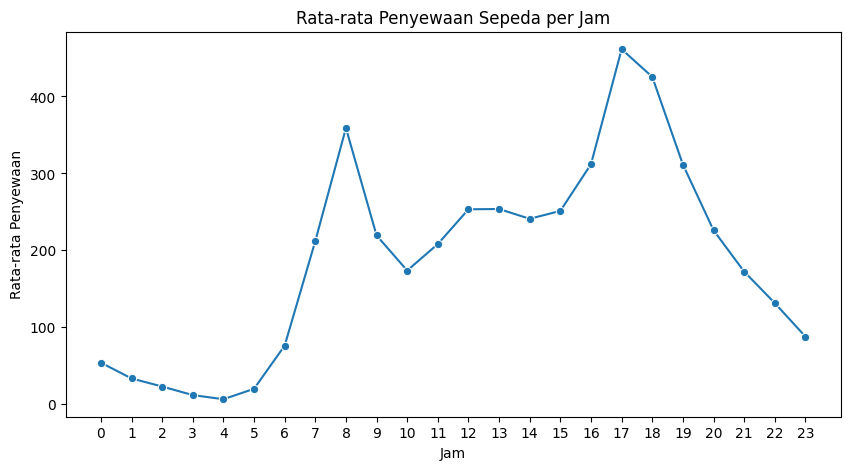

In [47]:
hour_plot = hour_df.groupby("hr")["cnt"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(
    data=hour_plot,
    x="hr",
    y="cnt",
    marker="o"
)

plt.title("Rata-rata Penyewaan Sepeda per Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(range(0,24))
plt.show()

**Insight:**
- Puncak penyewaan sepeda terjadi pada pukul 17.00.
- Lonjakan penyewaan juga terjadi pada pukul 08.00 dan 18.00.
- Pola ini menunjukkan sepeda banyak digunakan pada jam berangkat dan pulang kerja.
- Jam malam dan dini hari menunjukkan jumlah penyewaan paling rendah.

## Analisis Lanjutan (Opsional)

In [48]:
os.makedirs("dashboard", exist_ok=True)
hour_df.to_csv("dashboard/main_data.csv", index=False)

## Conclusion



## Conclusion Pertanyaan 1  
Bagaimana pengaruh kategori suhu terhadap rata-rata jumlah penyewaan sepeda?

Berdasarkan hasil analisis, kategori suhu memiliki pengaruh yang jelas terhadap jumlah penyewaan sepeda. Kategori Hangat mencatat rata-rata penyewaan tertinggi, yaitu sekitar 5.663 penyewaan per hari. Selanjutnya kategori Panas memiliki rata-rata sekitar 5.423 penyewaan per hari. Kategori Sedang menunjukkan rata-rata sekitar 3.750 penyewaan per hari, sedangkan kategori Dingin memiliki rata-rata penyewaan terendah yaitu sekitar 1.700 penyewaan per hari.

Perbedaan ini menunjukkan bahwa suhu udara yang lebih nyaman cenderung meningkatkan minat masyarakat dalam menggunakan layanan penyewaan sepeda. Semakin hangat suhu udara, semakin tinggi aktivitas penyewaan sepeda.

Rekomendasi:
Menambah jumlah sepeda yang tersedia saat suhu Hangat dan Panas.
Menjalankan promosi khusus pada cuaca dingin untuk meningkatkan penggunaan.


## Conclusion Pertanyaan 2  
Pada jam berapa rata-rata jumlah penyewaan sepeda mencapai puncaknya?

Hasil analisis menunjukkan bahwa rata-rata jumlah penyewaan tertinggi terjadi pada **pukul 17.00** dengan rata-rata sekitar **461** penyewaan per jam. Posisi berikutnya terjadi pada **pukul 18.00** sebesar **425** penyewaan dan **pukul 08.00** sebesar **359** penyewaan.

Jika dilihat berdasarkan pola waktu, jam sibuk terjadi pada pagi hari dan sore hari. Hal ini menunjukkan bahwa sepeda banyak digunakan sebagai sarana mobilitas harian, terutama untuk berangkat kerja, sekolah, dan pulang kerja.

### Rekomendasi:
- Menambah stok sepeda dan kesiapan petugas pada pukul **07.00–09.00** dan **16.00–18.00**.
- Melakukan perawatan sepeda di luar jam sibuk agar operasional tidak terganggu.
- Menambah titik stasiun sepeda di area perkantoran, kampus, dan halte transportasi umum.



## Kesimpulan Umum

Secara keseluruhan, faktor suhu dan waktu memiliki pengaruh besar terhadap permintaan penyewaan sepeda. Cuaca hangat meningkatkan penggunaan, sedangkan jam pulang kerja menjadi periode dengan permintaan tertinggi. Dengan menyesuaikan operasional berdasarkan pola ini, perusahaan dapat meningkatkan efisiensi layanan, kepuasan pelanggan, dan potensi pendapatan.